# PASO 2: Calidad de Datos

Este notebook realiza validaciones exhaustivas sobre la calidad del dataset **sin realizar transformaciones**. El objetivo es identificar problemas de calidad (valores faltantes, duplicados, inconsistencias, outliers) para documentarlos antes de la limpieza.

## 1. Setup - Importación de Librerías

Importamos las librerías necesarias para el análisis de calidad: pandas para manipulación de datos, numpy para cálculos numéricos, y matplotlib/seaborn para visualizaciones.

In [1]:
# Imports necesarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

## Carga del Dataset

Verificamos si el DataFrame `df` ya existe en memoria. Si no existe, lo cargamos desde el archivo CSV.

In [2]:
# Cargar dataset 
df = pd.read_csv('../data/transacciones_banco.csv')
print(f"✓ Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

✓ Dataset cargado: 2,512 filas x 16 columnas


---

## 2. Análisis de Valores Nulos (Missing Values)

Identificamos y cuantificamos los valores faltantes en cada columna del dataset.

In [3]:
print("=" * 80)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 80)

# Conteo de nulos por columna
nulos_count = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df)) * 100

# Crear DataFrame resumen ordenado descendente
resumen_nulos = pd.DataFrame({
    'Columna': nulos_count.index,
    'Valores_Nulos': nulos_count.values,
    'Porcentaje': nulos_pct.values
}).sort_values('Valores_Nulos', ascending=False)

print("\nColumnas con valores nulos (ordenado descendente):")
print(resumen_nulos[resumen_nulos['Valores_Nulos'] > 0].to_string(index=False))

if resumen_nulos['Valores_Nulos'].sum() == 0:
    print("\n✓ No se encontraron valores nulos en el dataset")

print(f"\n{'─' * 80}")
print(f"TOTAL de valores nulos: {nulos_count.sum():,}")
print(f"Porcentaje total missing: {(nulos_count.sum() / (len(df) * len(df.columns)) * 100):.2f}%")
print(f"Columnas con nulos: {(nulos_count > 0).sum()} de {len(df.columns)}")

ANÁLISIS DE VALORES NULOS

Columnas con valores nulos (ordenado descendente):
Empty DataFrame
Columns: [Columna, Valores_Nulos, Porcentaje]
Index: []

✓ No se encontraron valores nulos en el dataset

────────────────────────────────────────────────────────────────────────────────
TOTAL de valores nulos: 0
Porcentaje total missing: 0.00%
Columnas con nulos: 0 de 16


### Visualización: Heatmap de Valores Nulos

Generamos un heatmap para visualizar la distribución espacial de valores faltantes en el dataset.

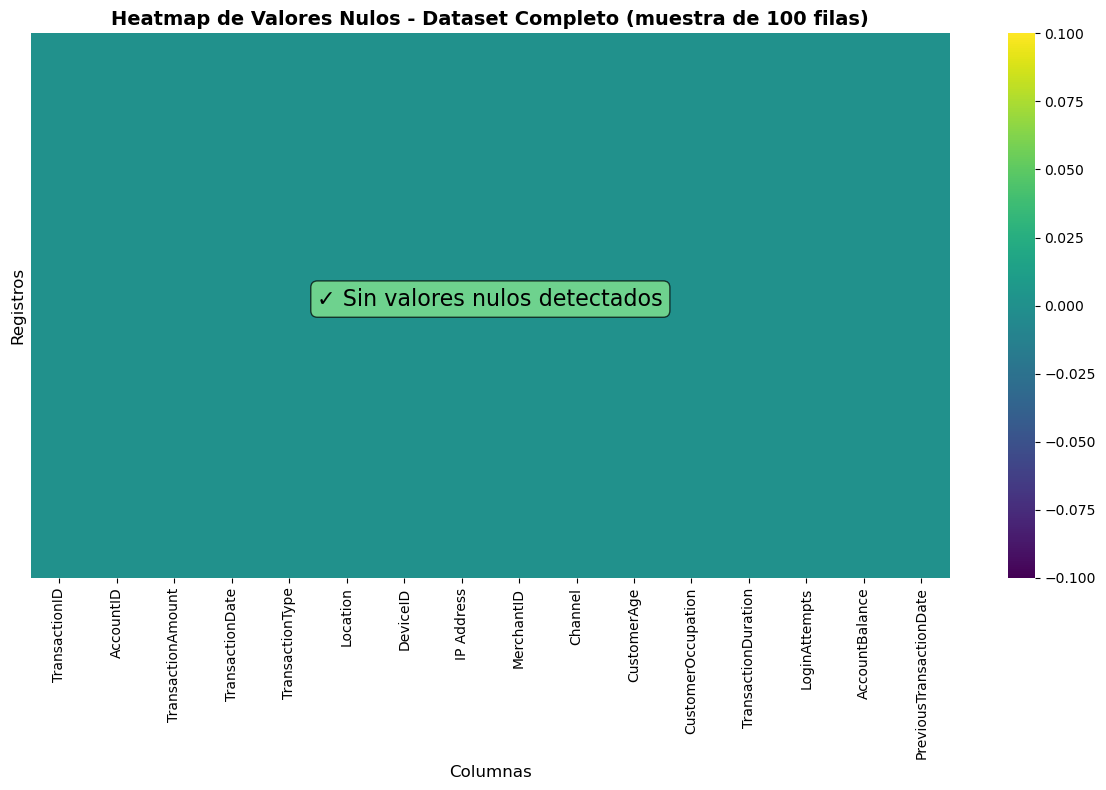

In [4]:
# Heatmap de valores nulos
fig, ax = plt.subplots(figsize=(12, 8))

# Seleccionar columnas con nulos (o todas si no hay nulos)
cols_con_nulos = resumen_nulos[resumen_nulos['Valores_Nulos'] > 0]['Columna'].tolist()

if len(cols_con_nulos) > 0:
    # Samplear filas si hay muchas (max 1000 para visualización)
    sample_size = min(1000, len(df))
    df_sample = df[cols_con_nulos].sample(n=sample_size, random_state=42)
    
    sns.heatmap(df_sample.isnull(), cbar=True, cmap='viridis', 
                yticklabels=False, ax=ax)
    plt.title(f'Heatmap de Valores Nulos (muestra de {sample_size} filas)', 
              fontsize=14, fontweight='bold')
else:
    # Si no hay nulos, mostrar heatmap de muestra pequeña
    sample_size = min(100, len(df))
    df_sample = df.sample(n=sample_size, random_state=42)
    sns.heatmap(df_sample.isnull(), cbar=True, cmap='viridis', 
                yticklabels=False, ax=ax)
    plt.title(f'Heatmap de Valores Nulos - Dataset Completo (muestra de {sample_size} filas)', 
              fontsize=14, fontweight='bold')
    ax.text(0.5, 0.5, '✓ Sin valores nulos detectados', 
            transform=ax.transAxes, fontsize=16, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.xlabel('Columnas', fontsize=12)
plt.ylabel('Registros', fontsize=12)
plt.tight_layout()
plt.show()

---

## 3. Análisis de Registros Duplicados

Identificamos si existen filas completamente duplicadas en el dataset.

In [5]:
print("=" * 80)
print("ANÁLISIS DE DUPLICADOS")
print("=" * 80)

# Contar duplicados
duplicados = df.duplicated().sum()
duplicados_pct = (duplicados / len(df)) * 100

print(f"\nNúmero de registros duplicados: {duplicados:,}")
print(f"Porcentaje de duplicados: {duplicados_pct:.2f}%")
print(f"Registros únicos: {len(df) - duplicados:,}")

if duplicados > 0:
    print(f"\n⚠ Se detectaron {duplicados:,} registros duplicados")
    print("\nMuestra de primeras filas duplicadas:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("\n✓ No se detectaron registros duplicados")

ANÁLISIS DE DUPLICADOS

Número de registros duplicados: 0
Porcentaje de duplicados: 0.00%
Registros únicos: 2,512

✓ No se detectaron registros duplicados


---

## 4. Unicidad y Cardinalidad de Identificadores

Evaluamos la unicidad de TransactionID y la cardinalidad de los principales identificadores.

In [6]:
print("=" * 80)
print("UNICIDAD Y CARDINALIDAD DE IDENTIFICADORES")
print("=" * 80)

# Verificar unicidad de TransactionID
if 'TransactionID' in df.columns:
    is_unique = df['TransactionID'].is_unique
    print(f"\nTransactionID es único: {is_unique}")
    if not is_unique:
        duplicados_id = df['TransactionID'].duplicated().sum()
        print(f"⚠ Hay {duplicados_id:,} TransactionIDs duplicados")
else:
    print("\n⚠ Columna 'TransactionID' no encontrada")

# Cardinalidad de identificadores
print(f"\n{'─' * 80}")
print("CARDINALIDAD DE IDENTIFICADORES:")
print("─" * 80)

columnas_ids = ['TransactionID', 'AccountID', 'MerchantID', 
                'DeviceID', 'IP Address', 'Location']

cardinalidad_data = {}
for col in columnas_ids:
    if col in df.columns:
        nunique = df[col].nunique()
        total = len(df)
        pct = (nunique / total) * 100
        cardinalidad_data[col] = {
            'Valores_Unicos': nunique,
            'Total_Registros': total,
            'Porcentaje_Unicidad': f"{pct:.2f}%"
        }
        print(f"{col:20s}: {nunique:,} valores únicos ({pct:.2f}%)")

# Preparar datos para gráfico
cols_disponibles = [col for col in columnas_ids if col in df.columns]
valores_unicos = [df[col].nunique() for col in cols_disponibles]

UNICIDAD Y CARDINALIDAD DE IDENTIFICADORES

TransactionID es único: True

────────────────────────────────────────────────────────────────────────────────
CARDINALIDAD DE IDENTIFICADORES:
────────────────────────────────────────────────────────────────────────────────
TransactionID       : 2,512 valores únicos (100.00%)
AccountID           : 495 valores únicos (19.71%)
MerchantID          : 100 valores únicos (3.98%)
DeviceID            : 681 valores únicos (27.11%)
IP Address          : 592 valores únicos (23.57%)
Location            : 43 valores únicos (1.71%)


### Visualización: Cardinalidad de Identificadores (Top 6)

Gráfico de barras mostrando la cantidad de valores únicos en los principales identificadores.

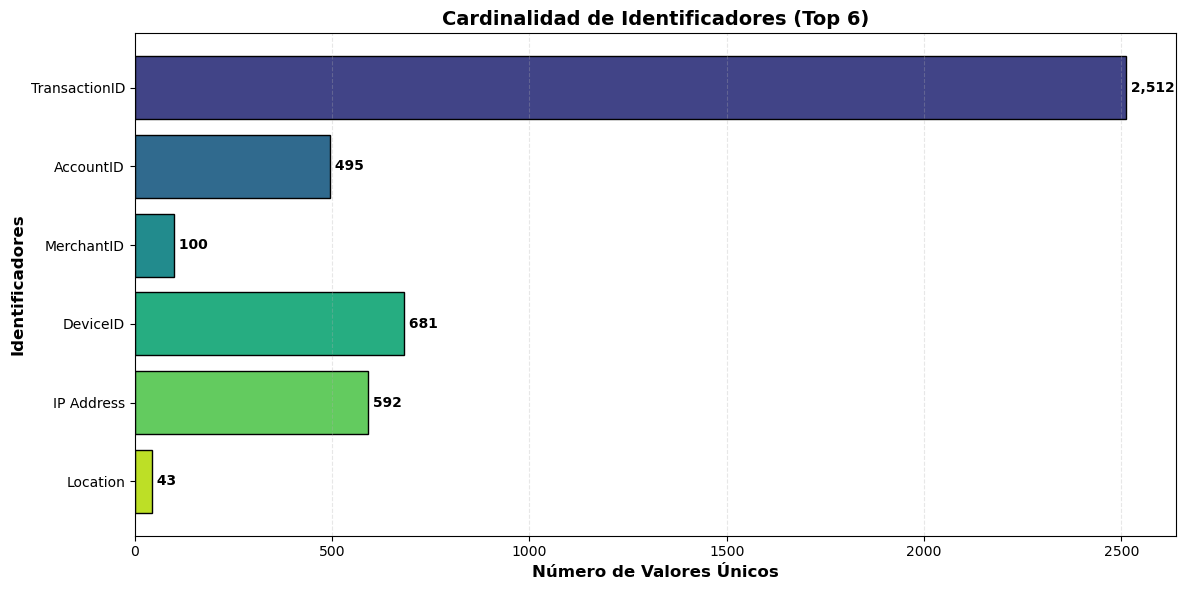


Interpretación:
- 100% unicidad = Clave primaria candidata
- < 100% = Valores repetidos (esperado en AccountID, Location, etc.)


In [7]:
# Gráfico de barras de cardinalidad
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(cols_disponibles)))
bars = ax.barh(cols_disponibles, valores_unicos, color=colors, edgecolor='black')

# Etiquetas en las barras
for i, (col, val) in enumerate(zip(cols_disponibles, valores_unicos)):
    ax.text(val, i, f' {val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Número de Valores Únicos', fontsize=12, fontweight='bold')
ax.set_ylabel('Identificadores', fontsize=12, fontweight='bold')
ax.set_title('Cardinalidad de Identificadores (Top 6)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.invert_yaxis()  # Invertir para que el primero esté arriba

plt.tight_layout()
plt.show()

print(f"\nInterpretación:")
print(f"- 100% unicidad = Clave primaria candidata")
print(f"- < 100% = Valores repetidos (esperado en AccountID, Location, etc.)")

---

## 5. Validación de Rangos Numéricos (Sanity Checks)

Verificamos si existen valores fuera de rangos lógicos en las variables numéricas clave.

In [8]:
print("=" * 80)
print("SANITY CHECKS - RANGOS NUMÉRICOS")
print("=" * 80)

problemas_rangos = {}

# 1. TransactionAmount <= 0
if 'TransactionAmount' in df.columns:
    count_ta_invalid = (df['TransactionAmount'] <= 0).sum()
    problemas_rangos['TransactionAmount <= 0'] = count_ta_invalid
    print(f"\nTransactionAmount <= 0: {count_ta_invalid:,} registros")
    if count_ta_invalid > 0:
        print(f"  ⚠ {count_ta_invalid:,} transacciones con monto <= 0")

# 2. AccountBalance < 0
if 'AccountBalance' in df.columns:
    count_ab_negative = (df['AccountBalance'] < 0).sum()
    problemas_rangos['AccountBalance < 0'] = count_ab_negative
    print(f"\nAccountBalance < 0: {count_ab_negative:,} registros")
    if count_ab_negative > 0:
        print(f"  ⚠ {count_ab_negative:,} cuentas con saldo negativo")

# 3. CustomerAge fuera de [0, 120]
if 'CustomerAge' in df.columns:
    count_age_invalid = ((df['CustomerAge'] < 0) | (df['CustomerAge'] > 120)).sum()
    problemas_rangos['CustomerAge fuera [0,120]'] = count_age_invalid
    print(f"\nCustomerAge fuera de [0, 120]: {count_age_invalid:,} registros")
    if count_age_invalid > 0:
        print(f"  ⚠ {count_age_invalid:,} edades fuera del rango esperado")
        print(f"  Min: {df['CustomerAge'].min()}, Max: {df['CustomerAge'].max()}")

# 4. TransactionDuration <= 0
if 'TransactionDuration' in df.columns:
    count_td_invalid = (df['TransactionDuration'] <= 0).sum()
    problemas_rangos['TransactionDuration <= 0'] = count_td_invalid
    print(f"\nTransactionDuration <= 0: {count_td_invalid:,} registros")
    if count_td_invalid > 0:
        print(f"  ⚠ {count_td_invalid:,} transacciones con duración <= 0")

# 5. LoginAttempts < 0
if 'LoginAttempts' in df.columns:
    count_la_negative = (df['LoginAttempts'] < 0).sum()
    problemas_rangos['LoginAttempts < 0'] = count_la_negative
    print(f"\nLoginAttempts < 0: {count_la_negative:,} registros")
    if count_la_negative > 0:
        print(f"  ⚠ {count_la_negative:,} registros con intentos negativos")

# Resumen
print(f"\n{'─' * 80}")
total_problemas = sum(problemas_rangos.values())
print(f"TOTAL de registros con problemas de rango: {total_problemas:,}")

SANITY CHECKS - RANGOS NUMÉRICOS

TransactionAmount <= 0: 0 registros

AccountBalance < 0: 0 registros

CustomerAge fuera de [0, 120]: 0 registros

TransactionDuration <= 0: 0 registros

LoginAttempts < 0: 0 registros

────────────────────────────────────────────────────────────────────────────────
TOTAL de registros con problemas de rango: 0


### Visualización: Distribución y Outliers de Montos y Saldos

Boxplots para identificar outliers en TransactionAmount y AccountBalance.

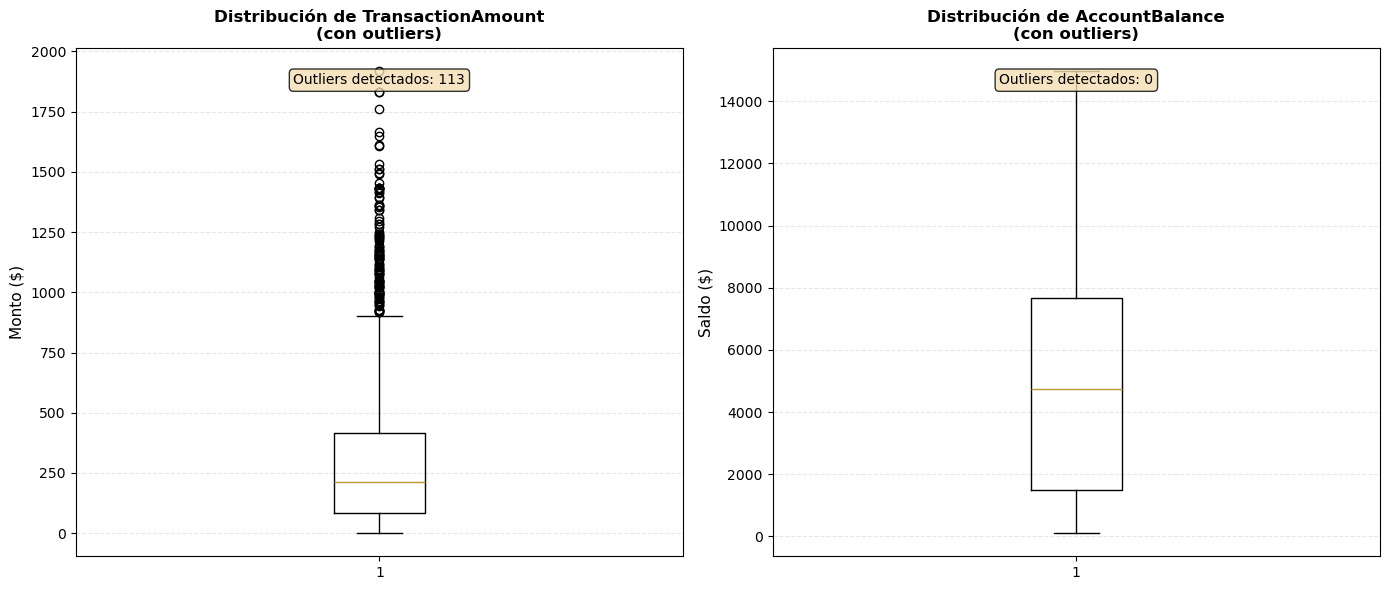


Nota: Los outliers no son necesariamente errores, pueden ser transacciones legítimas.


In [9]:
# Boxplots de TransactionAmount y AccountBalance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# TransactionAmount
if 'TransactionAmount' in df.columns:
    axes[0].boxplot(df['TransactionAmount'].dropna(), vert=True)
    axes[0].set_title('Distribución de TransactionAmount\n(con outliers)', 
                      fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Monto ($)', fontsize=11)
    axes[0].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Estadísticas
    q1 = df['TransactionAmount'].quantile(0.25)
    q3 = df['TransactionAmount'].quantile(0.75)
    iqr = q3 - q1
    outliers_ta = ((df['TransactionAmount'] < (q1 - 1.5 * iqr)) | 
                   (df['TransactionAmount'] > (q3 + 1.5 * iqr))).sum()
    axes[0].text(0.5, 0.95, f'Outliers detectados: {outliers_ta:,}', 
                transform=axes[0].transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# AccountBalance
if 'AccountBalance' in df.columns:
    axes[1].boxplot(df['AccountBalance'].dropna(), vert=True)
    axes[1].set_title('Distribución de AccountBalance\n(con outliers)', 
                      fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Saldo ($)', fontsize=11)
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')
    
    # Estadísticas
    q1 = df['AccountBalance'].quantile(0.25)
    q3 = df['AccountBalance'].quantile(0.75)
    iqr = q3 - q1
    outliers_ab = ((df['AccountBalance'] < (q1 - 1.5 * iqr)) | 
                   (df['AccountBalance'] > (q3 + 1.5 * iqr))).sum()
    axes[1].text(0.5, 0.95, f'Outliers detectados: {outliers_ab:,}', 
                transform=axes[1].transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print("\nNota: Los outliers no son necesariamente errores, pueden ser transacciones legítimas.")

---

## 6. Consistencias de Negocio

Verificamos reglas de negocio que podrían indicar anomalías o fraudes.

In [10]:
print("=" * 80)
print("CONSISTENCIAS DE NEGOCIO")
print("=" * 80)

problemas_negocio = {}

# 1. TransactionAmount > AccountBalance
if 'TransactionAmount' in df.columns and 'AccountBalance' in df.columns:
    count_excede_saldo = (df['TransactionAmount'] > df['AccountBalance']).sum()
    problemas_negocio['Monto > Saldo'] = count_excede_saldo
    print(f"\nTransactionAmount > AccountBalance: {count_excede_saldo:,} registros")
    pct = (count_excede_saldo / len(df)) * 100
    print(f"  Porcentaje: {pct:.2f}%")
    if count_excede_saldo > 0:
        print(f"  ⚠ Posibles sobregiros o retiros no autorizados")

# 2. LoginAttempts >= 4 (posible indicador de riesgo)
if 'LoginAttempts' in df.columns:
    count_high_attempts = (df['LoginAttempts'] >= 4).sum()
    problemas_negocio['LoginAttempts >= 4'] = count_high_attempts
    print(f"\nLoginAttempts >= 4: {count_high_attempts:,} registros")
    pct = (count_high_attempts / len(df)) * 100
    print(f"  Porcentaje: {pct:.2f}%")
    if count_high_attempts > 0:
        print(f"  ⚠ Posibles intentos de acceso no autorizado")

print(f"\n{'─' * 80}")
total_problemas_negocio = sum(problemas_negocio.values())
print(f"TOTAL de registros con inconsistencias de negocio: {total_problemas_negocio:,}")

CONSISTENCIAS DE NEGOCIO

TransactionAmount > AccountBalance: 119 registros
  Porcentaje: 4.74%
  ⚠ Posibles sobregiros o retiros no autorizados

LoginAttempts >= 4: 64 registros
  Porcentaje: 2.55%
  ⚠ Posibles intentos de acceso no autorizado

────────────────────────────────────────────────────────────────────────────────
TOTAL de registros con inconsistencias de negocio: 183


### Visualización: Distribución de Intentos de Login

Histograma/countplot de LoginAttempts para identificar patrones sospechosos.

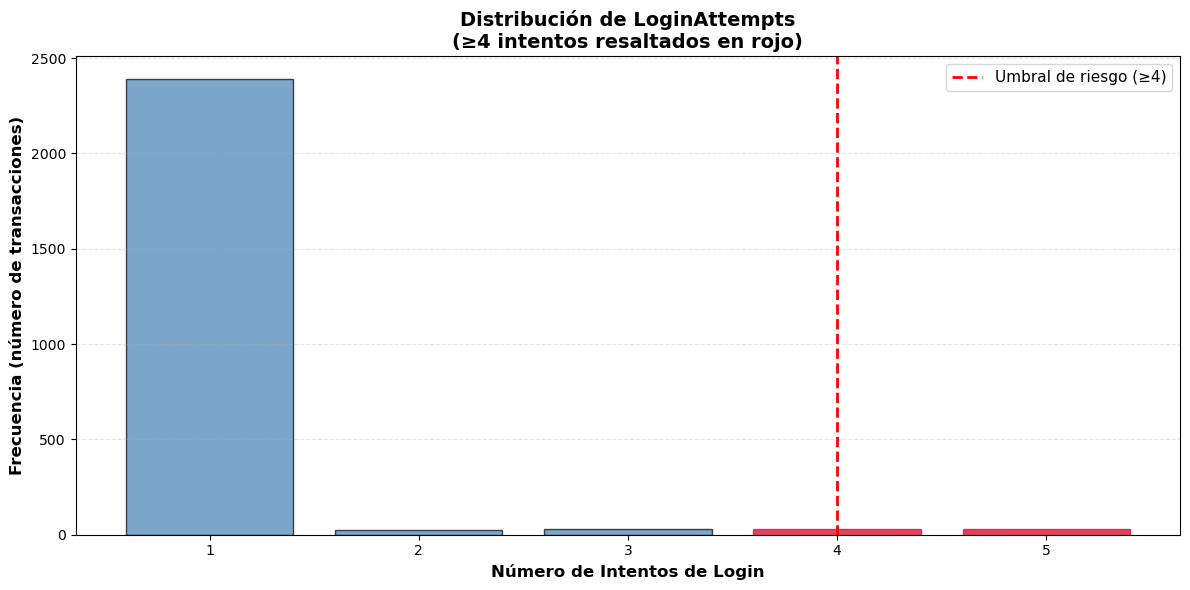


Estadísticas de LoginAttempts:
  Media: 1.12
  Mediana: 1.0
  Máximo: 5
  Transacciones con ≥4 intentos: 64


In [11]:
# Histograma de LoginAttempts
if 'LoginAttempts' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Contar frecuencias
    login_counts = df['LoginAttempts'].value_counts().sort_index()
    
    bars = ax.bar(login_counts.index, login_counts.values, 
                  color='steelblue', edgecolor='black', alpha=0.7)
    
    # Resaltar intentos >= 4 en rojo
    for i, (attempts, count) in enumerate(zip(login_counts.index, login_counts.values)):
        if attempts >= 4:
            bars[i].set_color('crimson')
            bars[i].set_alpha(0.8)
    
    ax.set_xlabel('Número de Intentos de Login', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia (número de transacciones)', fontsize=12, fontweight='bold')
    ax.set_title('Distribución de LoginAttempts\n(≥4 intentos resaltados en rojo)', 
                 fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Línea vertical en 4
    ax.axvline(x=4, color='red', linestyle='--', linewidth=2, 
               label='Umbral de riesgo (≥4)')
    ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nEstadísticas de LoginAttempts:")
    print(f"  Media: {df['LoginAttempts'].mean():.2f}")
    print(f"  Mediana: {df['LoginAttempts'].median():.1f}")
    print(f"  Máximo: {df['LoginAttempts'].max()}")
    print(f"  Transacciones con ≥4 intentos: {(df['LoginAttempts'] >= 4).sum():,}")
else:
    print("⚠ Columna 'LoginAttempts' no encontrada")

---

## 7. Validación de Fechas (Parseo y Consistencia Temporal)

Parseamos las columnas de fechas y validamos su consistencia lógica.

In [12]:
print("=" * 80)
print("ANÁLISIS DE FECHAS")
print("=" * 80)

# Parsear TransactionDate
if 'TransactionDate' in df.columns:
    print("\n[1] TransactionDate:")
    print(f"    Tipo original: {df['TransactionDate'].dtype}")
    print(f"    Muestra: {df['TransactionDate'].head(3).tolist()}")
    
    df['TransactionDate_dt'] = pd.to_datetime(df['TransactionDate'], errors='coerce')
    
    parse_fail_td = df['TransactionDate_dt'].isna().sum()
    parse_fail_pct_td = (parse_fail_td / len(df)) * 100
    
    print(f"\n    Parse failures: {parse_fail_td:,} ({parse_fail_pct_td:.2f}%)")
    
    if parse_fail_td == 0:
        print(f"    ✓ Todas las fechas parseadas correctamente")
        print(f"    Rango temporal:")
        print(f"      - Min: {df['TransactionDate_dt'].min()}")
        print(f"      - Max: {df['TransactionDate_dt'].max()}")
        print(f"      - Duración: {(df['TransactionDate_dt'].max() - df['TransactionDate_dt'].min()).days} días")
    else:
        print(f"    ⚠ {parse_fail_td:,} fechas no pudieron ser parseadas")

# Parsear PreviousTransactionDate
if 'PreviousTransactionDate' in df.columns:
    print(f"\n{'─' * 80}")
    print("\n[2] PreviousTransactionDate:")
    print(f"    Tipo original: {df['PreviousTransactionDate'].dtype}")
    print(f"    Muestra: {df['PreviousTransactionDate'].head(3).tolist()}")
    
    df['PreviousTransactionDate_dt'] = pd.to_datetime(df['PreviousTransactionDate'], errors='coerce')
    
    parse_fail_ptd = df['PreviousTransactionDate_dt'].isna().sum()
    parse_fail_pct_ptd = (parse_fail_ptd / len(df)) * 100
    
    print(f"\n    Parse failures: {parse_fail_ptd:,} ({parse_fail_pct_ptd:.2f}%)")
    
    if parse_fail_ptd == 0 or (len(df) - parse_fail_ptd) > 0:
        valid_dates = df['PreviousTransactionDate_dt'].dropna()
        if len(valid_dates) > 0:
            print(f"    Rango temporal:")
            print(f"      - Min: {valid_dates.min()}")
            print(f"      - Max: {valid_dates.max()}")
            if pd.notna(valid_dates.min()) and pd.notna(valid_dates.max()):
                print(f"      - Duración: {(valid_dates.max() - valid_dates.min()).days} días")

# Consistencia temporal: PreviousTransactionDate > TransactionDate
if 'TransactionDate_dt' in df.columns and 'PreviousTransactionDate_dt' in df.columns:
    print(f"\n{'─' * 80}")
    print("\n[3] Consistencia Temporal:")
    
    # Filtrar registros con ambas fechas válidas
    mask_valid = df['TransactionDate_dt'].notna() & df['PreviousTransactionDate_dt'].notna()
    count_valid = mask_valid.sum()
    
    if count_valid > 0:
        inconsistentes = (df.loc[mask_valid, 'PreviousTransactionDate_dt'] > 
                         df.loc[mask_valid, 'TransactionDate_dt']).sum()
        pct_inconsistentes = (inconsistentes / count_valid) * 100
        
        print(f"    Registros con ambas fechas válidas: {count_valid:,}")
        print(f"    PreviousTransactionDate > TransactionDate: {inconsistentes:,} ({pct_inconsistentes:.2f}%)")
        
        if inconsistentes > 0:
            print(f"    ⚠ Inconsistencia lógica: la fecha previa es POSTERIOR a la actual")
        else:
            print(f"    ✓ Todas las fechas son consistentes")
    else:
        print(f"    ⚠ No hay registros con ambas fechas válidas para comparar")

ANÁLISIS DE FECHAS

[1] TransactionDate:
    Tipo original: object
    Muestra: ['2023-04-11 16:29:14', '2023-06-27 16:44:19', '2023-07-10 18:16:08']

    Parse failures: 0 (0.00%)
    ✓ Todas las fechas parseadas correctamente
    Rango temporal:
      - Min: 2023-01-02 16:00:06
      - Max: 2024-01-01 18:21:50
      - Duración: 364 días

────────────────────────────────────────────────────────────────────────────────

[2] PreviousTransactionDate:
    Tipo original: object
    Muestra: ['2024-11-04 08:08:08', '2024-11-04 08:09:35', '2024-11-04 08:07:04']

    Parse failures: 0 (0.00%)
    Rango temporal:
      - Min: 2024-11-04 08:06:23
      - Max: 2024-11-04 08:12:23
      - Duración: 0 días

────────────────────────────────────────────────────────────────────────────────

[3] Consistencia Temporal:
    Registros con ambas fechas válidas: 2,512
    PreviousTransactionDate > TransactionDate: 2,512 (100.00%)
    ⚠ Inconsistencia lógica: la fecha previa es POSTERIOR a la actual


### Visualización: Distribución Temporal de Transacciones

Histograma mensual de TransactionDate para identificar patrones temporales.

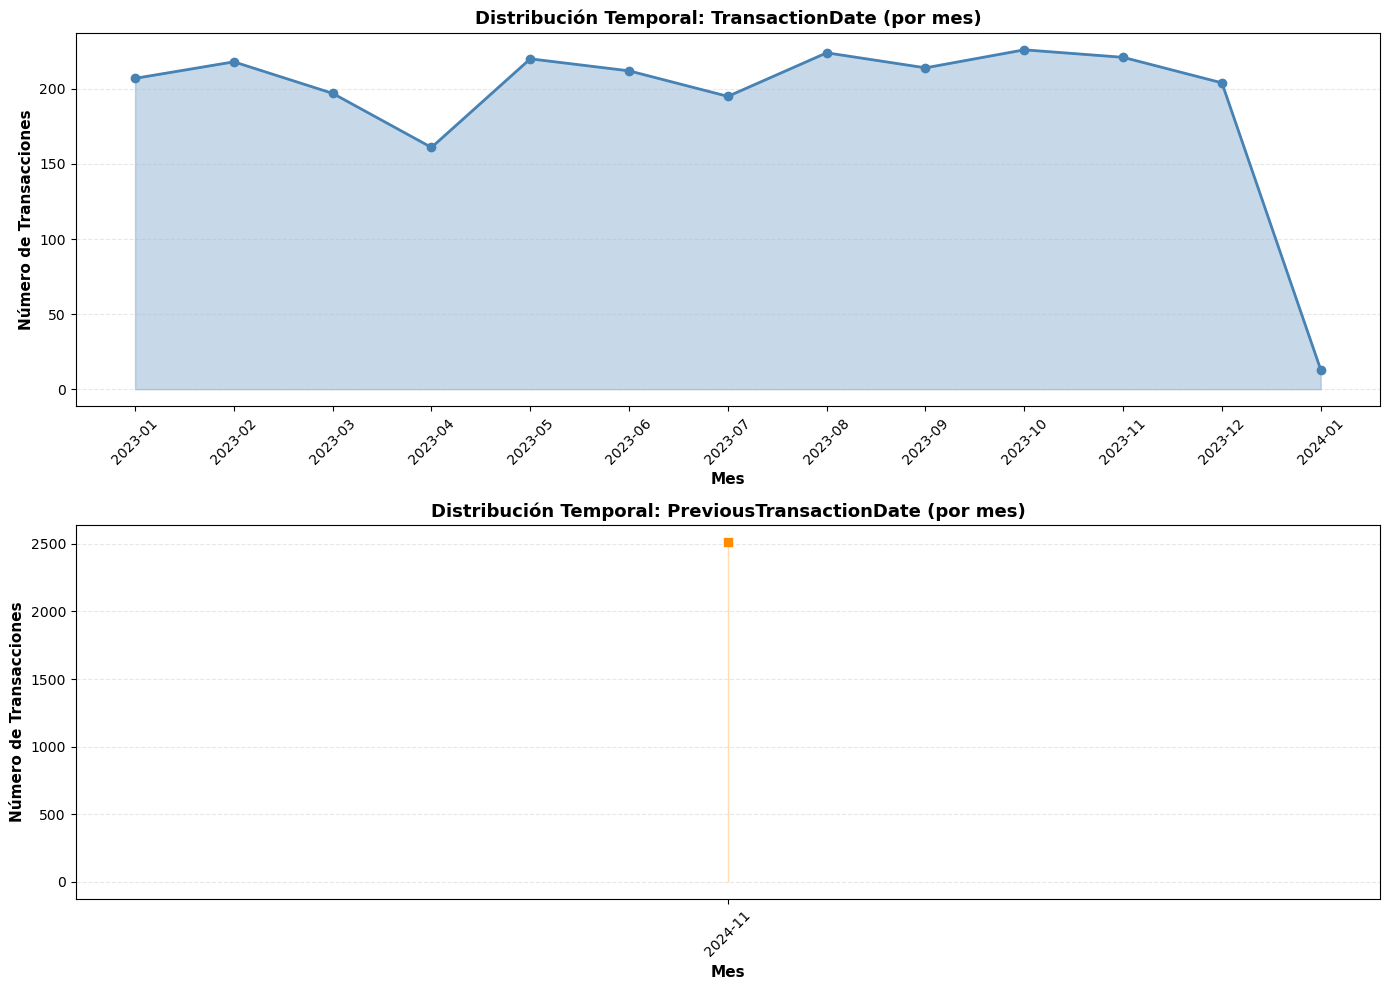

In [13]:
# Histograma temporal de transacciones
if 'TransactionDate_dt' in df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # [1] TransactionDate por mes
    df_valid_td = df[df['TransactionDate_dt'].notna()].copy()
    
    if len(df_valid_td) > 0:
        df_valid_td['YearMonth'] = df_valid_td['TransactionDate_dt'].dt.to_period('M')
        transacciones_por_mes = df_valid_td['YearMonth'].value_counts().sort_index()
        
        axes[0].plot(transacciones_por_mes.index.astype(str), 
                    transacciones_por_mes.values, 
                    marker='o', linewidth=2, markersize=6, color='steelblue')
        axes[0].fill_between(range(len(transacciones_por_mes)), 
                            transacciones_por_mes.values, 
                            alpha=0.3, color='steelblue')
        axes[0].set_xlabel('Mes', fontsize=11, fontweight='bold')
        axes[0].set_ylabel('Número de Transacciones', fontsize=11, fontweight='bold')
        axes[0].set_title('Distribución Temporal: TransactionDate (por mes)', 
                         fontsize=13, fontweight='bold')
        axes[0].grid(axis='y', alpha=0.3, linestyle='--')
        axes[0].tick_params(axis='x', rotation=45)
    else:
        axes[0].text(0.5, 0.5, 'No hay fechas válidas para graficar', 
                    transform=axes[0].transAxes, ha='center', va='center',
                    fontsize=14)
    
    # [2] PreviousTransactionDate por mes (si existe)
    if 'PreviousTransactionDate_dt' in df.columns:
        df_valid_ptd = df[df['PreviousTransactionDate_dt'].notna()].copy()
        
        if len(df_valid_ptd) > 0:
            df_valid_ptd['YearMonth'] = df_valid_ptd['PreviousTransactionDate_dt'].dt.to_period('M')
            prev_trans_por_mes = df_valid_ptd['YearMonth'].value_counts().sort_index()
            
            axes[1].plot(prev_trans_por_mes.index.astype(str), 
                        prev_trans_por_mes.values, 
                        marker='s', linewidth=2, markersize=6, color='darkorange')
            axes[1].fill_between(range(len(prev_trans_por_mes)), 
                                prev_trans_por_mes.values, 
                                alpha=0.3, color='darkorange')
            axes[1].set_xlabel('Mes', fontsize=11, fontweight='bold')
            axes[1].set_ylabel('Número de Transacciones', fontsize=11, fontweight='bold')
            axes[1].set_title('Distribución Temporal: PreviousTransactionDate (por mes)', 
                             fontsize=13, fontweight='bold')
            axes[1].grid(axis='y', alpha=0.3, linestyle='--')
            axes[1].tick_params(axis='x', rotation=45)
        else:
            axes[1].text(0.5, 0.5, 'No hay fechas previas válidas para graficar', 
                        transform=axes[1].transAxes, ha='center', va='center',
                        fontsize=14)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No se pudo crear el gráfico temporal (columna TransactionDate_dt no existe)")